# RL agent sims (260723): model characterisation by centrality strategy

~55 social (2-agent) self-play models trained in `Octagon/results/2607/260723`, all for 3e6 steps. Per `270723_notes.txt` this batch was run with **the penalty-break clause definitely removed from the build**, to check whether the 260715 results hold. The penalty break is believed to have been erroneously included in the 260715 build, so this batch is not a plain seed replicate of it — expect the resting metrics to move.

The goal is to split the between-model variability into a *gross strategy* axis and *intra-strategy variability*, then pick a spread of models for a tournament.

**The characterisation axis is centrality at slice onset.** For each trial, at the frame the walls appear, centrality `= 1 - r/R` (1 = arena centre, 0 = at a wall). A model's mean over trials is roughly where it stands when the trial starts, and defines a broadly central or broadly peripheral waiting strategy.

**Plan**
1. **Gross strategy** — per-model slice-onset centrality, split into central vs peripheral.
2. **Intra-strategy variability** — how the other behavioural metrics vary within each strategy, and which metrics separate the strategies vs vary freely inside them.
3. A shortlist of models for the tournament.

**Choices** (matching prior sim notebooks): FoV = 110.0; both agents pooled (self-play); everything that computes a number comes from `analysis/model_characterisation.py`, which loads through `parse_data.prepare_sim_data` and takes slice-onset position from `get_indices.get_player_slice_onset_loc`.

**Note on metrics.** The fingerprint metric for complete rest means no translational or rotational movement. Technically, this is a proxy, as it is calculated from positional information and not the actual decisions of the agents themselves. Therefore, if an agent is e.g. running into a wall, it will be taking action but considered resting. I have checked this across the 260715 models, and found that the difference between these two metrics is tiny. So, I am ignoring it for now as using position is much more convenient

### Results:
#### Fingerprints:
- 260723 has the same onset and iti centrality
- 260723 has longer path length in both models
- Mean scores are similar
- Latency is much lower, with a stronger effect for peripheral than central (central 0.4 -> 0.3, 25% decrease; peripheral 1.3 -> 0.6, ~50% decrease)
- fraction never visible has always been low, but peripheral drops from 0.02 to 0.01; central is at floor already
- path length increases disproportionately for peripheral (central 37 -> 43; peripheral 16 -> 33)
- proportion resting decreases massively (central 0.1 -> 0.03; peripheral 0.5 -> 0.11), though large spread for perihperal in both
- proportion_no_translational decreases (central 0.25 -> 0.125, 50% decrease; peripheral 0.65 -> 0.25)
- proportion_no_rotational decreases (central 0.375 -> 0.2; peripheral 0.775 -> 0.420)
- rotation total increases (central 1175 -> 1425; 400 -> 1050)
- interestingly frac_visible_at_onset stays the same (central 0.68; peripheral 0.88)
- frac_trials_over_5s decreases for peripheral; already at floor for central (perihperal 0.02 -> 0.01)
- p_high is identical for central, but drops for peripheral (0.7 -> 0.625)

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_strings
import analysis.model_characterisation as mc
import plotting.plot_octagon as plot_octagon

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

# social self-play inference logs for this run live in a dated subfolder
SIM_DATA_FOLDER = os.path.join(data_strings.SIM_DATA_FOLDER, '2607', '260723')

CURRENT_FOV = 110.0                 # agent camera FoV (total degrees)

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            # every run in this batch trained for 3e6 steps, so there is no training-length split
ALL_MODELS = mc.get_batch_models(SIM_DATA_FOLDER)
print(f"models found: {len(ALL_MODELS)}")
print(ALL_MODELS)

models found: 55
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]


## Main pass over all models

One pass per model builds the long tables: `slice` (slice-onset centrality and x,z, one row per trial x agent), `iti`, `vis`, `score` and `rt`. Each model is loaded, measured, then discarded, so the batch stays memory-safe. Slice-onset x,z are kept so the occupancy heatmaps can be split by strategy after classification. Runs with no completed trials are skipped.

In [3]:
tables = mc.collect_model_data(SIM_DATA_FOLDER, models=ALL_MODELS, fov=CURRENT_FOV)
USABLE_MODELS = mc.summarise_collection(tables, ALL_MODELS)
slice_df, iti_df = tables['slice'], tables['iti']

model  1 done  model  2 done  model  3 done  model  4 done  model  5 done  model  6 done  model  7 done  model  8 done  model  9 done  model 10 done  model 11 done  model 12 done  model 13 done  model 14 done  model 15 done  model 16 done  model 17 done  model 18 done  model 19 done  model 20 done  model 21 done  model 22 done  model 23 done  model 24 done  model 25 done  model 26 done  model 27 done  model 28 done  model 29 done  model 30 done  model 31 done  model 32 done  model 33 done  model 34 done  model 35 done  model 36 done  model 37 done  model 38 done  model 39 done  model 40 done  model 41 done  model 42 done  model 43 done  model 44 done  model 45 done  model 46 done  model 47 done  model 48 done  model 49 done  model 50 done  model 51 done  model 52 done  model 53 done  model 54 done  model 55 done  

usable models: 55 / 55
slice-onset rows: 21722 | ITIs: 21722 | visibility rows: 21722 | scored trials: 10861
trials per model: min 189, max 198


## Stage 1 - the strategy axis (centrality at slice onset)

Each model's mean slice-onset centrality summarises its strategy. Models are ranked by it (bar = mean, whisker = SD across trials), with the spread of individual trials shown below. A tight spread means the model starts most trials from a similar distance out; a wide one means its start position varies a lot.

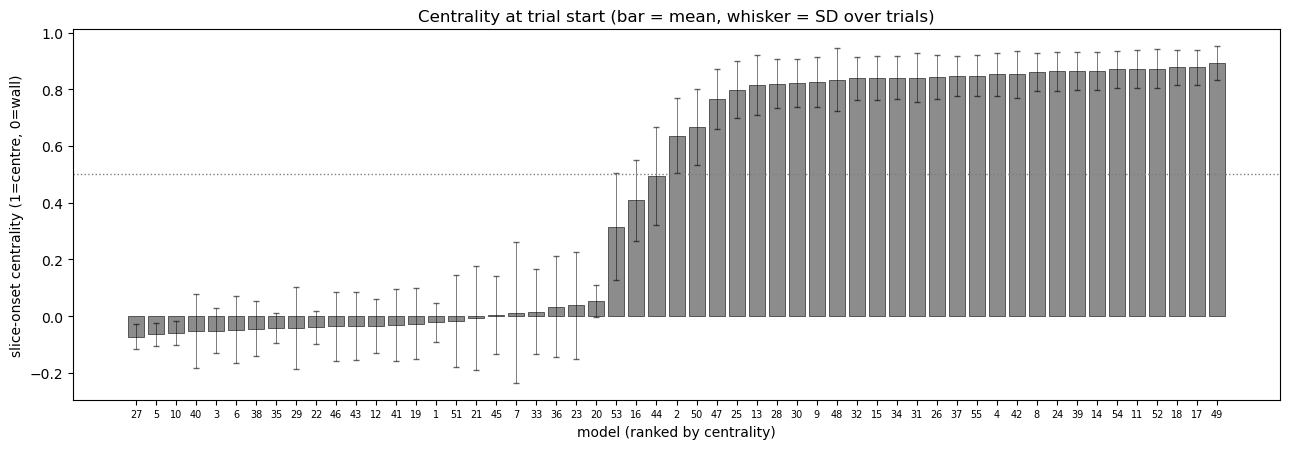

In [4]:
onset_by_model = mc.onset_centrality_by_model(slice_df)

order = onset_by_model.sort_values('onset_centrality').reset_index(drop=True)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.bar(x, order['onset_centrality'], yerr=order['onset_sd'], capsize=2,
       color='#8C8C8C', edgecolor='black', linewidth=0.4,
       error_kw=dict(lw=0.6, alpha=0.6))

ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels(order['model'], fontsize=7)
ax.set_xlabel('model (ranked by centrality)'); ax.set_ylabel('slice-onset centrality (1=centre, 0=wall)')
ax.set_title('Centrality at trial start (bar = mean, whisker = SD over trials)')
plt.tight_layout(); plt.show()

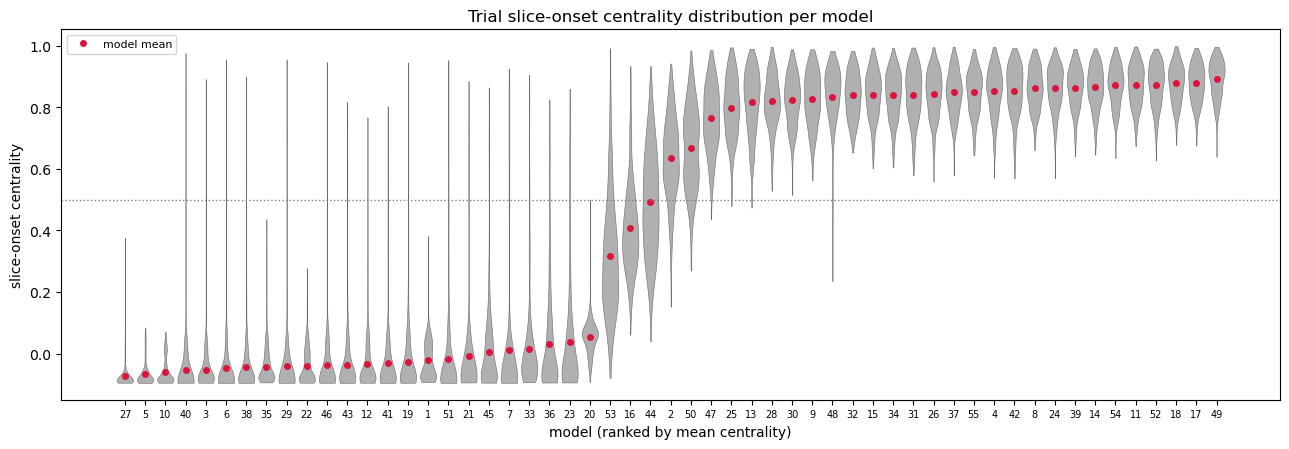

In [5]:
# plot the per-trial spread within each model, ordered by model mean
fig, ax = plt.subplots(figsize=(13, 4.6))
mean_order = onset_by_model.sort_values('onset_centrality')['model'].tolist()
sns.violinplot(data=slice_df, x='model', y='centrality', order=mean_order,
               density_norm='width', inner=None, cut=0, linewidth=0.4,
               color='#B0B0B0', ax=ax)
ax.plot(range(len(mean_order)),
        onset_by_model.set_index('model').loc[mean_order, 'onset_centrality'].values,
        'o', color='crimson', markersize=4, label='model mean')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xticks(range(len(mean_order)))
ax.set_xticklabels(mean_order, fontsize=7)
ax.set_xlabel('model (ranked by mean centrality)'); ax.set_ylabel('slice-onset centrality')
ax.set_title('Trial slice-onset centrality distribution per model')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Data-driven central vs peripheral split

Are "central" and "peripheral" two separate clusters, or just ends of one continuous range? The models are split two ways. (a) A fixed cut at centrality = 0.5, nearer the centre than a wall. (b) A 2-component Gaussian mixture fit to the per-model means, which finds its own boundary. If the two splits agree and the distribution has a clear gap, the split is real. If they disagree over a smooth spread, centrality is a sliding scale, not two groups.

A third mixture component then picks out models sitting between the two clusters, which are tagged `intermediate`. They stay in the fingerprint table but are left out of the group comparisons and their figures. Posterior probability cannot find these models, as the tight peripheral component drives every posterior to 1.0.

GMM component means: [-0.024  0.791]  weights: [0.56 0.44]
fixed(0.5) vs GMM agreement: 95%
strategy_gmm  strategy_fixed
central       central           28
              peripheral         3
peripheral    peripheral        24
Name: n, dtype: int64


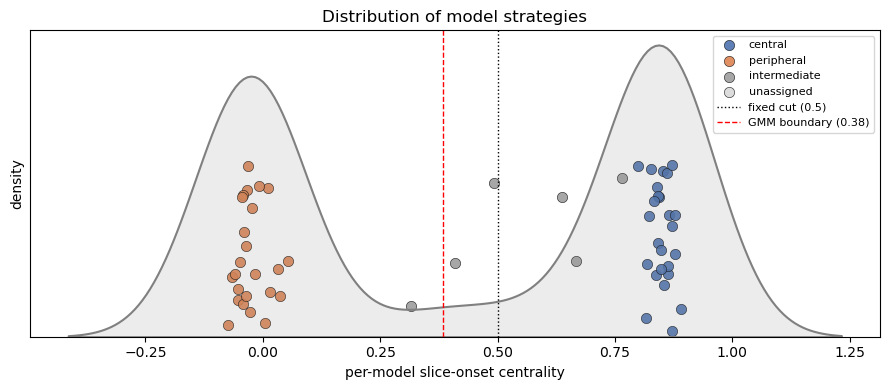

In [6]:
onset_by_model, gmm, boundary = mc.split_strategies(onset_by_model)
mc.report_strategy_split(onset_by_model, gmm)

vals = onset_by_model['onset_centrality'].to_numpy()
fig, ax = plt.subplots(figsize=(9, 4))
for lab, col in mc.STRAT_PALETTE.items():
    sub = onset_by_model[onset_by_model['strategy'] == lab]
    ax.scatter(sub['onset_centrality'], np.random.uniform(0, 1, len(sub)),
               color=col, edgecolor='black', linewidth=0.4, s=55, alpha=0.9, label=lab)
sns.kdeplot(x=vals, ax=ax, color='grey', lw=1.5, fill=True, alpha=0.15, bw_adjust=0.6)
ax.axvline(0.5, color='black', ls=':', lw=1, label='fixed cut (0.5)')
ax.axvline(boundary, color='red', ls='--', lw=1, label=f'GMM boundary ({boundary:.2f})')
ax.set_yticks([]); ax.set_xlabel('per-model slice-onset centrality'); ax.set_ylabel('density')
ax.set_title('Distribution of model strategies')
ax.legend(fontsize=8, loc='upper right'); plt.tight_layout(); plt.show()

In [7]:
# adopt the three-way label as the working strategy; every label is carried for transparency
model_meta = mc.build_model_meta(USABLE_MODELS, onset_by_model, strategy_col='strategy')

# for this batch, keep only the three models nearest the midpoint between the two clusters as
# intermediate. The other three the mixture flagged sit up against the central cluster, so they
# are set aside rather than forced into a group
INTERMEDIATE = [16, 44, 53]
set_aside = (model_meta['strategy'] == 'intermediate') & ~model_meta['model'].isin(INTERMEDIATE)
model_meta.loc[set_aside, 'strategy'] = 'unassigned'

mc.report_strategy_membership(model_meta)


Strategy membership (working label = GMM):
  central     (n=25): [4, 8, 9, 11, 13, 14, 15, 17, 18, 24, 25, 26, 28, 30, 31, 32, 34, 37, 39, 42, 48, 49, 52, 54, 55]
  peripheral  (n=24): [1, 3, 5, 6, 7, 10, 12, 19, 20, 21, 22, 23, 27, 29, 33, 35, 36, 38, 40, 41, 43, 45, 46, 51]
  intermediate (n= 3): [16, 44, 53]
  unassigned  (n= 3): [2, 47, 50]


## Stage 2 - intra-strategy variability

Collect a set of behavioural metrics per model. For each one, compare how much it differs **between** the two strategies against how much it differs **within** a strategy. Metrics that differ mostly between strategies are what central vs peripheral actually captures. Metrics that vary a lot within a strategy tell otherwise-similar models apart in some other way.

In [8]:
fingerprint = mc.build_fingerprint(model_meta, tables)
fingerprint[['model', 'strategy'] + mc.FP_METRICS].round(3)

,model,strategy,onset_centrality,iti_centrality,prop_no_translational,prop_no_rotational,proportion_resting,iti_path_len,rot_total,winner_path_len,path_ratio,frac_visible_at_onset,late_latency_to_wall_visible,all_latency_to_wall_visible,latency_to_reach_wall,frac_never_visible,frac_trials_over_5s,p_high,mean_score,score_rate
0,1,peripheral,-0.022,-0.012,0.267,0.413,0.114,33.355,1049.437,20.156,1.220,0.909,0.425,0.023,2.080,0.038,0.000,0.662,0.448,0.387
1,2,unassigned,0.637,0.516,0.116,0.267,0.034,43.800,1313.037,20.858,1.206,0.702,0.401,0.120,2.107,0.000,0.000,0.737,0.396,0.398
2,3,peripheral,-0.052,-0.038,0.248,0.514,0.131,32.552,868.982,20.622,1.275,0.937,0.133,0.004,2.250,0.033,0.000,0.601,0.397,0.356
3,4,central,0.853,0.750,0.121,0.166,0.023,43.501,1493.601,19.512,1.124,0.717,0.284,0.080,1.944,0.000,0.000,0.778,0.389,0.439
4,5,peripheral,-0.065,-0.055,0.289,0.360,0.105,29.532,1145.582,18.948,1.246,0.874,0.375,0.020,2.240,0.078,0.005,0.571,0.348,0.363
5,6,peripheral,-0.048,-0.036,0.364,0.450,0.168,26.841,985.691,20.666,1.220,0.927,0.392,0.019,2.303,0.025,0.005,0.621,0.380,0.354
6,7,peripheral,0.012,0.014,0.395,0.456,0.189,24.999,976.146,19.562,1.231,0.836,0.528,0.057,2.407,0.063,0.000,0.646,0.366,0.376
7,8,central,0.861,0.765,0.107,0.218,0.025,44.289,1403.346,21.668,1.215,0.712,0.291,0.084,2.220,0.000,0.000,0.894,0.555,0.422
8,9,central,0.827,0.763,0.164,0.195,0.032,41.434,1445.000,20.269,1.153,0.699,0.254,0.076,2.034,0.000,0.000,0.818,0.438,0.434
9,10,peripheral,-0.059,-0.054,0.253,0.509,0.130,32.178,877.746,21.582,1.358,0.833,0.624,0.049,2.553,0.096,0.010,0.571,0.329,0.323


In [9]:
var_table = mc.between_strategy_variance(fingerprint)
print("Between-strategy variance share (eta^2): 1 = fully explained by strategy, 0 = all within-strategy")
var_table.round(3)

Between-strategy variance share (eta^2): 1 = fully explained by strategy, 0 = all within-strategy


,metric,eta2_between_strategy,p_anova,central_mean,peripheral_mean
0,onset_centrality,0.996,0.000,0.849,-0.024
1,iti_centrality,0.992,0.000,0.778,-0.012
15,p_high,0.825,0.000,0.862,0.620
5,iti_path_len,0.752,0.000,43.229,32.726
17,score_rate,0.746,0.000,0.442,0.341
6,rot_total,0.712,0.000,1448.079,1050.660
3,prop_no_rotational,0.711,0.000,0.192,0.413
4,proportion_resting,0.685,0.000,0.027,0.108
9,frac_visible_at_onset,0.641,0.000,0.684,0.860
2,prop_no_translational,0.607,0.000,0.128,0.252


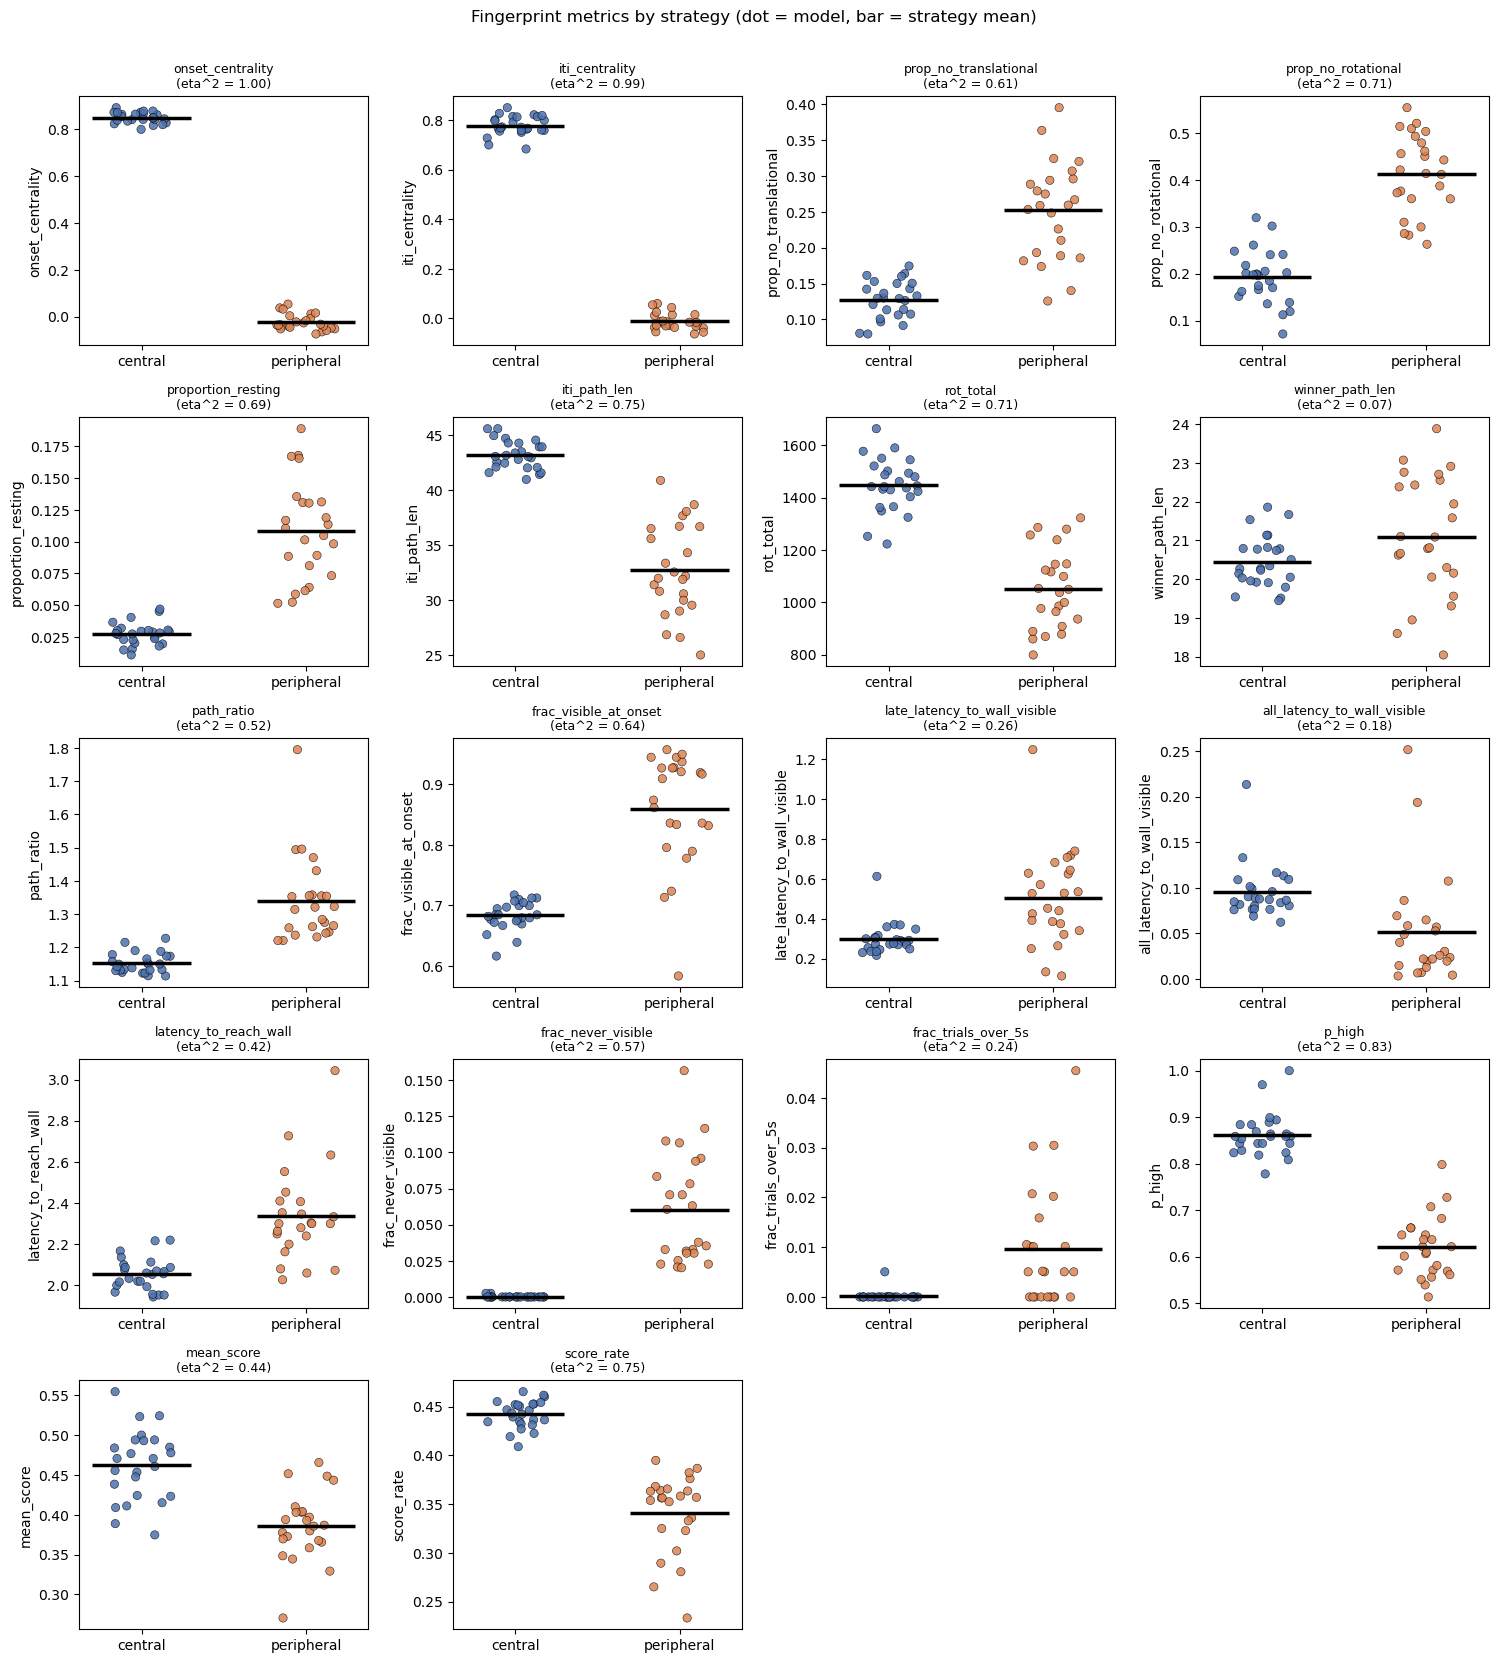

In [10]:
# plot central vs peripheral for each fingerprint metric (dot = model, bar = strategy mean).
# intermediate models are left out, as they belong to neither group
ncol = 4
nrow = int(np.ceil(len(mc.FP_METRICS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.3 * nrow))
fp_main = fingerprint[fingerprint['strategy'].isin(mc.MAIN_STRATEGIES)]
for ax, m in zip(axes.ravel(), mc.FP_METRICS):
    sns.stripplot(data=fp_main, x='strategy', y=m, order=list(mc.MAIN_STRATEGIES),
                  hue='strategy', palette=mc.STRAT_PALETTE, size=6, jitter=0.18,
                  alpha=0.85, edgecolor='black', linewidth=0.4, legend=False, ax=ax)
    means = fp_main.groupby('strategy')[m].mean()
    for i, g in enumerate(mc.MAIN_STRATEGIES):
        ax.hlines(means[g], i - 0.3, i + 0.3, color='black', lw=2.5, zorder=5)
    e = var_table.set_index('metric').loc[m, 'eta2_between_strategy']
    ax.set_title(f'{m}\n(eta^2 = {e:.2f})', fontsize=9); ax.set_xlabel('')
for ax in axes.ravel()[len(mc.FP_METRICS):]:
    ax.axis('off')
plt.suptitle('Fingerprint metrics by strategy (dot = model, bar = strategy mean)', y=1.005)
plt.tight_layout(); plt.show()

### Where each strategy stands at slice onset

Occupancy of the slice-onset position, split by strategy, with the octagon outline.

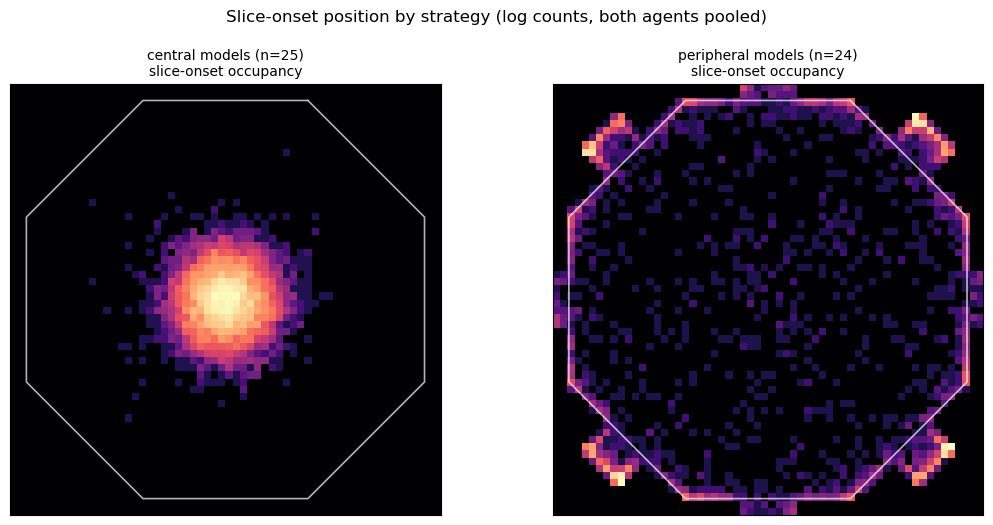

In [11]:
HIST_BINS = 60
R = mc.ARENA_RADIUS
extent = [-R, R, -R, R]
hrange = [[-R, R], [-R, R]]
slice_df['strategy'] = slice_df['model'].map(model_meta.set_index('model')['strategy'])

oct_x, oct_y = plot_octagon.calculate_coordinates(vertex=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, lab in zip(axes, mc.MAIN_STRATEGIES):
    sub = slice_df[slice_df['strategy'] == lab]
    H, _, _ = np.histogram2d(sub['x'].to_numpy(float), sub['z'].to_numpy(float),
                             bins=HIST_BINS, range=hrange)
    ax.imshow(np.log1p(H).T, origin='lower', extent=extent, cmap='magma', aspect='equal')
    ax.plot(oct_x, oct_y, color='white', lw=1.2, alpha=0.7)
    ax.set_title(f'{lab} models (n={(model_meta.strategy == lab).sum()})\nslice-onset occupancy', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Slice-onset position by strategy (log counts, both agents pooled)', y=1.0)
plt.tight_layout(); plt.show()

### When each strategy first sees a wall

Cumulative proportion of trials with a trial wall in the FoV, measured from slice onset. A trial that ended before a wall came into view never counts as seen, so each curve plateaus at `1 - frac_never_visible` rather than reaching 1. The lower panel gives the share of trials still running, which is what makes that plateau readable.


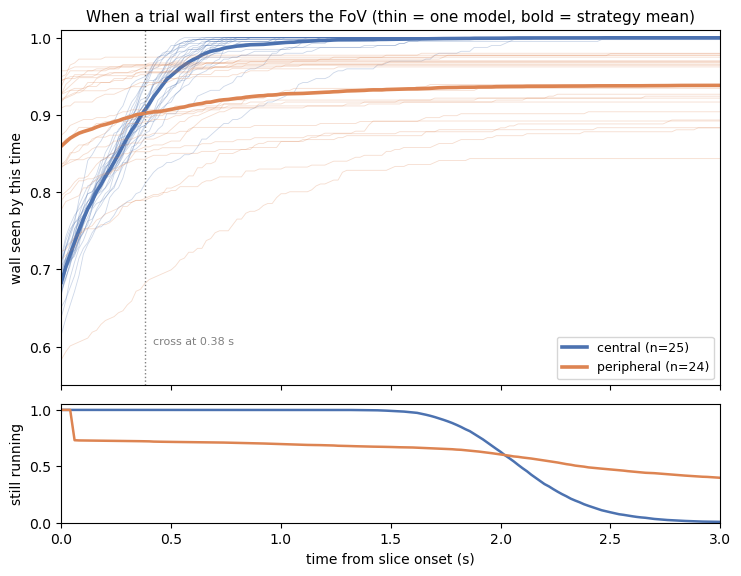

In [12]:
# take the cumulative visibility curve for every model
curve = mc.wall_visible_curve(tables['vis'], model_meta, max_s=3.0)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(8.5, 6.4), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
for lab in mc.MAIN_STRATEGIES:
    sub = curve[curve['strategy'] == lab]
    # plot one thin line per model, so within-strategy spread stays visible
    for _, g in sub.groupby('model'):
        ax.plot(g['t'], g['p_visible'], color=mc.STRAT_PALETTE[lab], lw=0.6, alpha=0.28)
    # plot the strategy mean over the top
    m = sub.groupby('t')[['p_visible', 'p_running']].mean()
    ax.plot(m.index, m['p_visible'], color=mc.STRAT_PALETTE[lab], lw=2.6,
            label=f"{lab} (n={sub['model'].nunique()})")
    # plot how many trials are still going, which sets where the curve above can plateau
    axr.plot(m.index, m['p_running'], color=mc.STRAT_PALETTE[lab], lw=1.8)

# mark where the two strategy means cross over
means = (curve[curve['strategy'].isin(mc.MAIN_STRATEGIES)]
         .groupby(['strategy', 't'])['p_visible'].mean().unstack(0))
ahead = (means['central'] - means['peripheral']).to_numpy() > 0
if ahead.any():
    cross = means.index[np.argmax(ahead)]
    ax.axvline(cross, color='grey', ls=':', lw=1)
    ax.annotate(f'cross at {cross:.2f} s', (cross, 0.60), xytext=(6, 0),
                textcoords='offset points', fontsize=8, color='grey', va='bottom')

ax.set_ylim(0.55, 1.01); ax.set_ylabel('wall seen by this time')
ax.set_title('When a trial wall first enters the FoV (thin = one model, bold = strategy mean)',
             fontsize=11)
ax.legend(fontsize=9, loc='lower right')
axr.set_ylim(0, 1.05); axr.set_xlim(0, 3)
axr.set_ylabel('still running'); axr.set_xlabel('time from slice onset (s)')
plt.show()


## Stage 3 - multivariate fingerprint & tournament shortlist

PCA of the standardised metrics shows whether centrality is the main thing separating these models, or just one of several. Then a shortlist for the tournament: the two extremes, the most typical model of each strategy (its medoid), and the best in-session scorer of each. This spans the range of strategies while including the strongest models.

PC1 explains 57%, PC2 15% of fingerprint variance
corr(PC1, slice-onset centrality) = +0.94  (|r|~1 => centrality is the main axis; ~0 => something else is)


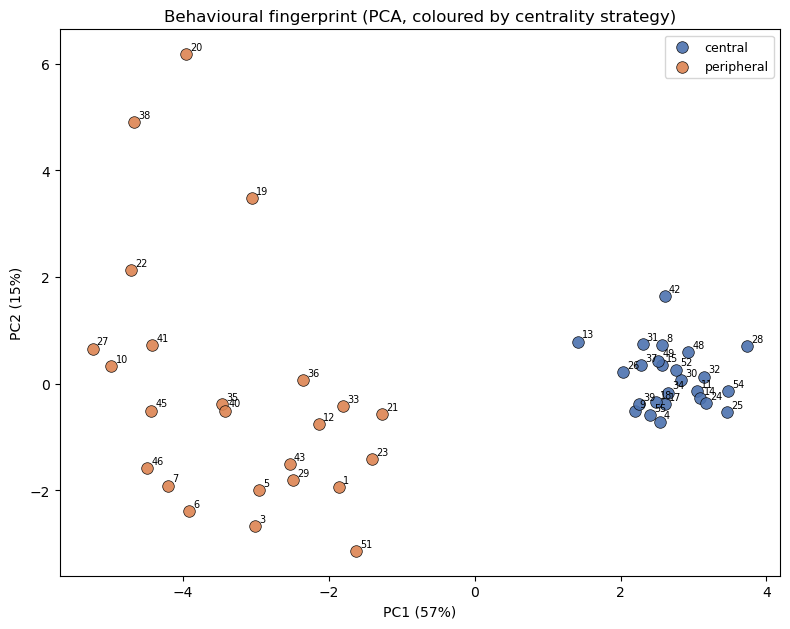

In [13]:
fingerprint, pca = mc.add_fingerprint_pca(fingerprint)
mc.report_pca(fingerprint, pca)

fig, ax = plt.subplots(figsize=(8, 6.4))
for lab in mc.MAIN_STRATEGIES:
    sub = fingerprint[fingerprint['strategy'] == lab]
    ax.scatter(sub['pc1'], sub['pc2'], s=70, color=mc.STRAT_PALETTE[lab],
               edgecolor='black', linewidth=0.5, label=lab, alpha=0.9)
for _, r in fingerprint[fingerprint['strategy'].isin(mc.MAIN_STRATEGIES)].iterrows():
    ax.annotate(int(r['model']), (r['pc1'], r['pc2']), fontsize=7, xytext=(3, 3),
                textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('Behavioural fingerprint (PCA, coloured by centrality strategy)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

In [14]:
shortlist = mc.tournament_shortlist(fingerprint, extra_cols=())
print("Suggested tournament shortlist (spans the strategy axis, includes strongest in-session scorers):")
print("NB in-session score is a self-play proxy only — the tournament is the real ranking.")
shortlist.round(3)

Suggested tournament shortlist (spans the strategy axis, includes strongest in-session scorers):
NB in-session score is a self-play proxy only — the tournament is the real ranking.


,role,model,strategy,onset_centrality,score_rate,p_high,mean_score
0,most_central,49,central,0.891,0.431,0.854,0.484
1,most_peripheral,27,peripheral,-0.074,0.289,0.513,0.270
2,typical_central,34,central,0.841,0.442,0.843,0.477
3,best_scorer_central,25,central,0.799,0.465,0.864,0.454
4,typical_peripheral,36,peripheral,0.032,0.357,0.646,0.387
5,best_scorer_peripheral,35,peripheral,-0.043,0.395,0.609,0.378


## Stage 4 - picking the best models of a strategy

Ranks the models of one strategy on how well they play, rather than how typical they are. The
work is mostly in the peripheral group. The central models are near-identical, so any of them
stands in for the others.

Every metric carries equal weight. Both standardising methods are run: robust z (median and a
scaled MAD) is the default, and mean of signed z-scores is shown alongside it. The two usually
agree, and where they differ the metric values below say why.

In [15]:
SHORTLIST_N = 5                      # how many models to shortlist per strategy
STRATEGY = 'peripheral'              # the group the ranking does real work on

# run both methods, print the two shortlists, the rank agreement, and how far outliers pull
# each metric. sd_over_mad above 1 means the SD is stretched by the tails
comparison = mc.report_method_comparison(fingerprint, strategy=STRATEGY, n=SHORTLIST_N)

  robust shortlist     [35, 1, 33, 51, 23]
  classic shortlist    [35, 33, 51, 1, 23]
  in both              [1, 23, 33, 35, 51]
  in one only          []
  rank agreement       Spearman 0.991 over 24 models

  biggest movers (+ = better under robust):
    model 29  classic #12 -> robust # 9  (+3)
    model  1  classic # 4 -> robust # 2  (+2)
    model  7  classic # 9 -> robust #11  (-2)

  outlier pull per metric (sd_over_mad > 1 = the SD is stretched by the tails):
    latency_to_reach_wall      sd/mad 1.46  influence classic 1.00 vs robust 1.46  | furthest model 22 at +4.8 robust units
    score_rate                 sd/mad 1.34  influence classic 1.00 vs robust 1.34  | furthest model 41 at -4.1 robust units
    frac_visible_at_onset      sd/mad 1.13  influence classic 1.00 vs robust 1.13  | furthest model 38 at -3.8 robust units
    winner_path_len            sd/mad 0.73  influence classic 1.00 vs robust 0.73  | furthest model 19 at +1.4 robust units


In [16]:
# the same comparison as a table, one row per model
comparison.round(3)

,model,strategy,rank_robust,quality_robust,top5_robust,rank_classic,quality_classic,top5_classic,move,shortlist
0,35,peripheral,1,0.798,True,1,0.993,True,0,both
1,1,peripheral,2,0.763,True,4,0.864,True,2,both
2,33,peripheral,3,0.717,True,2,0.913,True,-1,both
3,51,peripheral,4,0.677,True,3,0.888,True,-1,both
4,23,peripheral,5,0.448,True,5,0.651,True,0,both
5,5,peripheral,6,0.342,False,6,0.640,False,0,
6,3,peripheral,7,0.262,False,7,0.483,False,0,
7,6,peripheral,8,0.116,False,8,0.372,False,0,
8,29,peripheral,9,0.030,False,12,0.174,False,3,
9,46,peripheral,10,0.023,False,10,0.293,False,0,


In [17]:
# each ranking in full, with the metric values and standardised scores behind every rank
for method in mc.RANKING_METHODS:
    print()
    mc.report_selection(mc.rank_models(fingerprint, strategy=STRATEGY, n=SHORTLIST_N,
                                       method=method), n=SHORTLIST_N)

ranked = mc.rank_models(fingerprint, strategy=STRATEGY, n=SHORTLIST_N, method='robust',
                        verbose=True)
ranked.round(3)


top 5 of 24 peripheral models, robust standardising (+ = better than the group):
  1. model 35  quality +0.80  margin +0.04
       best latency_to_reach_wall +1.78 | weakest frac_visible_at_onset -1.27
  2. model  1  quality +0.76  margin +0.05
       best latency_to_reach_wall +1.43 | weakest frac_visible_at_onset +0.22
  3. model 33  quality +0.72  margin +0.04
       best latency_to_reach_wall +1.56 | weakest frac_visible_at_onset -0.69
  4. model 51  quality +0.68  margin +0.23  [few late trials]
       best latency_to_reach_wall +0.89 | weakest score_rate +0.31
  5. model 23  quality +0.45  margin +0.11
       best latency_to_reach_wall +0.65 | weakest frac_visible_at_onset +0.31

top 5 of 24 peripheral models, classic standardising (+ = better than the group):
  1. model 35  quality +0.99  margin +0.08
       best winner_path_len +2.00 | weakest frac_visible_at_onset -0.77
  2. model 33  quality +0.91  margin +0.02
       best winner_path_len +1.64 | weakest frac_visible_at_onse

,model,strategy,method,rank,quality,margin,picked,score_rate,latency_to_reach_wall,frac_visible_at_onset,winner_path_len,z_score_rate,z_latency_to_reach_wall,z_frac_visible_at_onset,z_winner_path_len,n_metrics,few_late_trials
0,35,peripheral,robust,1,0.798,0.035,True,0.395,2.027,0.789,18.044,1.292,1.779,-1.268,1.391,4,False
1,1,peripheral,robust,2,0.763,0.046,True,0.387,2.080,0.909,20.156,1.019,1.434,0.220,0.380,4,False
2,33,peripheral,robust,3,0.717,0.040,True,0.382,2.060,0.836,18.599,0.870,1.564,-0.690,1.125,4,False
3,51,peripheral,robust,4,0.677,0.230,True,0.366,2.163,0.949,19.308,0.308,0.893,0.722,0.786,4,True
4,23,peripheral,robust,5,0.448,0.106,True,0.368,2.200,0.917,20.055,0.396,0.652,0.314,0.428,4,False
5,5,peripheral,robust,6,0.342,0.080,False,0.363,2.240,0.874,18.948,0.238,0.391,-0.220,0.958,4,True
6,3,peripheral,robust,7,0.262,0.145,False,0.356,2.250,0.937,20.622,-0.001,0.326,0.565,0.157,4,True
7,6,peripheral,robust,8,0.116,0.086,False,0.354,2.303,0.927,20.666,-0.086,-0.023,0.439,0.136,4,True
8,29,peripheral,robust,9,0.030,0.008,False,0.363,2.300,0.944,22.554,0.230,-0.000,0.659,-0.768,4,True
9,46,peripheral,robust,10,0.023,0.038,False,0.358,2.410,0.957,21.100,0.063,-0.717,0.816,-0.072,4,True


### Metric values for the shortlisted models

Any set of models can go in `PICKS`. It defaults to every model that makes the top n under
either method, so the models the two methods disagree on are always included.

In [18]:
# take every model shortlisted by at least one method
PICKS = sorted(comparison.loc[comparison['shortlist'] != '', 'model'].astype(int))
print(f"models shortlisted by at least one method: {PICKS}")

# show what the ranking used: the raw value, its rank in the group, and the standardised score
# under both methods
mc.inspect_models(fingerprint, PICKS, strategy=STRATEGY).round(3)

models shortlisted by at least one method: [1, 23, 33, 35, 51]


,model,metric,value,rank_in_group,better,z_robust,z_classic
0,1,frac_visible_at_onset,0.909,12,higher,0.220,0.542
1,23,frac_visible_at_onset,0.917,11,higher,0.314,0.625
2,33,frac_visible_at_onset,0.836,15,higher,-0.690,-0.262
3,35,frac_visible_at_onset,0.789,20,higher,-1.268,-0.772
4,51,frac_visible_at_onset,0.949,2,higher,0.722,0.985
5,1,latency_to_reach_wall,2.080,4,lower,1.434,1.152
6,23,latency_to_reach_wall,2.200,6,lower,0.652,0.615
7,33,latency_to_reach_wall,2.060,2,lower,1.564,1.242
8,35,latency_to_reach_wall,2.027,1,lower,1.779,1.390
9,51,latency_to_reach_wall,2.163,5,lower,0.893,0.781


### What the ranking never sees

The fingerprint metrics left over once the ranking metrics are removed, plus any ranking metric
dropped for having too few trials. No better direction is implied here, so the rank is simply
the group ordering by value. This is where a model that ranks well can turn out to rest most of
the ITI, win the High wall rarely, or carry a slow-trial tail.

In [19]:
mc.hidden_metrics(fingerprint, PICKS, strategy=STRATEGY).round(3)

,model,metric,value,rank_high_to_low,group_median,dropped_from_ranking
0,1,all_latency_to_wall_visible,0.023,14,0.028,False
1,23,all_latency_to_wall_visible,0.022,15,0.028,False
2,33,all_latency_to_wall_visible,0.065,6,0.028,False
3,35,all_latency_to_wall_visible,0.086,4,0.028,False
4,51,all_latency_to_wall_visible,0.003,24,0.028,False
...,...,...,...,...,...,...
65,1,rot_total,1049.437,12,1043.237,False
66,23,rot_total,1037.037,13,1043.237,False
67,33,rot_total,1116.091,9,1043.237,False
68,35,rot_total,859.688,23,1043.237,False


### Robustness of the ranking

In [20]:
# re-rank with each metric dropped in turn. A model that holds its place however the metrics are
# cut is a firm pick; one that moves a long way is riding on a single metric
mc.rank_stability(fingerprint, strategy=STRATEGY).round(2)

,model,quality_all,rank_all,no_score_rate,no_latency_to_reach_wall,no_frac_visible_at_onset,no_late_latency_to_wall_visible,no_winner_path_len,rank_worst,rank_best,rank_spread
0,35,0.80,1,5,3,1,1,3,5,1,4
1,1,0.76,2,3,2,3,2,1,3,1,2
2,33,0.72,3,4,4,2,3,4,4,2,2
3,51,0.68,4,1,1,4,4,2,4,1,3
4,23,0.45,5,6,5,6,5,5,6,5,1
5,5,0.34,6,7,6,5,6,8,8,5,3
6,3,0.26,7,8,8,8,7,6,8,6,2
7,6,0.12,8,9,10,9,8,9,10,8,2
8,29,0.03,9,12,11,11,9,7,12,7,5
9,46,0.02,10,10,7,14,10,10,14,7,7


In [21]:
# rank correlations between the ranking metrics. Two that correlate strongly are one signal
# counted twice in the equal-weight average
mc.metric_overlap(fingerprint, strategy=STRATEGY).round(2)

,score_rate,latency_to_reach_wall,frac_visible_at_onset,late_latency_to_wall_visible,winner_path_len
score_rate,1.00,0.38,0.15,0.12,0.64
latency_to_reach_wall,0.38,1.00,0.12,0.08,0.61
frac_visible_at_onset,0.15,0.12,1.00,0.29,0.11
late_latency_to_wall_visible,0.12,0.08,0.29,1.00,0.16
winner_path_len,0.64,0.61,0.11,0.16,1.00


### The peripheral shortlist against typical central models

Two central models from the middle of their own quality ranking, set beside the peripheral
shortlist on the metrics the peripheral ranking used.

The quality scores elsewhere are standardised within a strategy, so they cannot put a central
model next to a peripheral one: each group is scaled against itself, and +1 means the best of
that group however tight the group is. This uses raw values instead, which distort nothing, with
a rank across all models in the batch as the common frame.

In [22]:
# take two middle-of-the-pack central models, ranked on the same metrics as the shortlist
CENTRAL_REF = mc.middle_models(fingerprint, 'central', n=2)
print(f"middle-of-the-pack central models: {CENTRAL_REF}")
print(f"peripheral shortlist:              {PICKS}")

# raw values with a batch-wide rank, so the two strategies share a frame. rank_in_batch is 1 for
# the best model of the whole batch on that metric, in the direction that counts as better
mc.compare_across_strategies(fingerprint, CENTRAL_REF + PICKS, ranked_within=STRATEGY).round(3)

middle-of-the-pack central models: [34, 39]
peripheral shortlist:              [1, 23, 33, 35, 51]


,metric,model,strategy,value,rank_in_batch,better,batch_median
0,frac_visible_at_onset,51,peripheral,0.949,2,higher,0.710
1,frac_visible_at_onset,23,peripheral,0.917,11,higher,0.710
2,frac_visible_at_onset,1,peripheral,0.909,12,higher,0.710
3,frac_visible_at_onset,33,peripheral,0.836,15,higher,0.710
4,frac_visible_at_onset,35,peripheral,0.789,20,higher,0.710
5,frac_visible_at_onset,34,central,0.705,30,higher,0.710
6,frac_visible_at_onset,39,central,0.674,45,higher,0.710
7,latency_to_reach_wall,39,central,2.020,11,lower,2.107
8,latency_to_reach_wall,35,peripheral,2.027,13,lower,2.107
9,latency_to_reach_wall,34,central,2.053,15,lower,2.107


### The central group for comparison

Included for completeness. The central models vary far less on every ranking metric, so their
order is close to arbitrary and they are better picked for coverage than by quality.

In [23]:
mc.rank_models(fingerprint, strategy='central', n=3, method='robust').round(3)

,model,strategy,method,rank,quality,margin,picked,score_rate,latency_to_reach_wall,frac_visible_at_onset,late_latency_to_wall_visible,winner_path_len,z_score_rate,z_latency_to_reach_wall,z_frac_visible_at_onset,z_late_latency_to_wall_visible,z_winner_path_len,n_metrics,few_late_trials
0,25,central,robust,1,1.118,0.320,True,0.465,1.957,0.694,0.248,19.446,1.612,1.551,0.450,0.815,1.165,5,False
1,4,central,robust,2,0.799,0.004,True,0.439,1.944,0.717,0.284,19.512,-0.292,1.752,1.461,-0.000,1.072,5,False
2,24,central,robust,3,0.795,0.183,True,0.460,1.953,0.679,0.269,19.542,1.231,1.605,-0.225,0.333,1.029,5,False
3,14,central,robust,4,0.612,0.171,False,0.446,1.967,0.710,0.291,19.908,0.199,1.388,1.124,-0.164,0.510,5,False
4,11,central,robust,5,0.441,0.038,False,0.453,2.020,0.699,0.272,20.268,0.684,0.566,0.674,0.277,0.002,5,False
5,55,central,robust,6,0.403,0.003,False,0.443,2.067,0.707,0.235,20.233,0.000,-0.163,1.012,1.113,0.052,5,False
6,54,central,robust,7,0.400,0.189,False,0.451,2.016,0.667,0.230,20.031,0.600,0.620,-0.787,1.231,0.336,5,False
7,30,central,robust,8,0.211,0.000,False,0.452,2.000,0.679,0.316,19.923,0.637,0.876,-0.225,-0.723,0.490,5,False
8,9,central,robust,9,0.210,0.033,False,0.434,2.034,0.699,0.254,20.269,-0.653,0.357,0.674,0.674,-0.000,5,False
9,17,central,robust,10,0.178,0.023,False,0.436,2.100,0.712,0.216,20.774,-0.508,-0.674,1.237,1.550,-0.714,5,False


#### OPTIONAL: Intermediate models ranked and chosen, for tournament use or comparison

In [24]:
INTERMEDIATE_N = 2

# only a handful of intermediate models, so the within-group scale is noisy.
# read it alongside the batch ranks further down
print(f"intermediate models in the batch: {(fingerprint.strategy == 'intermediate').sum()}")
for method in mc.RANKING_METHODS:
    print()
    mc.report_selection(mc.rank_models(fingerprint, strategy='intermediate',
                                       n=INTERMEDIATE_N, method=method), n=INTERMEDIATE_N)

inter = mc.rank_models(fingerprint, strategy='intermediate', n=INTERMEDIATE_N,
                       method='robust', verbose=True)
inter.round(3)


intermediate models in the batch: 3

top 2 of 3 intermediate models, robust standardising (+ = better than the group):
  1. model 16  quality +0.13  margin +0.30
       best score_rate +0.67 | weakest latency_to_reach_wall -0.00
  2. model 53  quality -0.16  margin +1.06
       best latency_to_reach_wall +0.67 | weakest frac_visible_at_onset -1.48

top 2 of 3 intermediate models, classic standardising (+ = better than the group):
  1. model 16  quality +0.43  margin +0.49
       best score_rate +1.00 | weakest late_latency_to_wall_visible -0.01
  2. model 53  quality -0.06  margin +0.31
       best latency_to_reach_wall +1.04 | weakest frac_visible_at_onset -1.35


,model,strategy,method,rank,quality,margin,picked,score_rate,latency_to_reach_wall,frac_visible_at_onset,late_latency_to_wall_visible,winner_path_len,z_score_rate,z_latency_to_reach_wall,z_frac_visible_at_onset,z_late_latency_to_wall_visible,z_winner_path_len,n_metrics,few_late_trials
0,16,intermediate,robust,1,0.135,0.297,True,0.439,1.86,0.697,0.344,19.042,0.674,-0.000,0.000,-0.000,-0.000,5,False
1,53,intermediate,robust,2,-0.162,1.058,True,0.422,1.76,0.641,0.371,18.716,0.000,0.674,-1.484,-0.674,0.674,5,False
2,44,intermediate,robust,3,-1.219,NaN,False,0.373,2.09,0.722,0.316,20.991,-1.880,-1.551,0.674,0.696,-4.035,5,False


In [25]:
# an intermediate model earns its place by sitting in the gap, so position matters
# as much as quality here
for s in ('central', 'peripheral'):
    sub = fingerprint[fingerprint.strategy == s]['onset_centrality']
    print(f"{s + ' centrality':<24} mean {sub.mean():+.3f}  "
          f"range {sub.min():+.3f} to {sub.max():+.3f}")

axis = (fingerprint[fingerprint.strategy == 'intermediate']
        [['model', 'onset_centrality', 'score_rate', 'p_high',
          'proportion_resting', 'frac_visible_at_onset']]
        .sort_values('onset_centrality', ascending=False))
axis['quality_rank'] = axis['model'].map(dict(zip(inter['model'], inter['rank'])))
axis.round(3)


central centrality       mean +0.849  range +0.799 to +0.891
peripheral centrality    mean -0.024  range -0.074 to +0.054


,model,onset_centrality,score_rate,p_high,proportion_resting,frac_visible_at_onset,quality_rank
43,44,0.493,0.373,0.667,0.028,0.722,3
15,16,0.408,0.439,0.773,0.037,0.697,1
52,53,0.316,0.422,0.672,0.026,0.641,2


In [26]:
INTERMEDIATE_PICKS = inter['model'].head(INTERMEDIATE_N).astype(int).tolist()
FIELD = CENTRAL_REF + INTERMEDIATE_PICKS + PICKS
print(f"field ({len(FIELD)}): central {CENTRAL_REF} | "
      f"intermediate {INTERMEDIATE_PICKS} | peripheral {PICKS}")

# raw values with a batch-wide rank, the only frame that spans strategies
mc.compare_across_strategies(fingerprint, FIELD, ranked_within=STRATEGY).round(3)


field (9): central [34, 39] | intermediate [16, 53] | peripheral [1, 23, 33, 35, 51]


,metric,model,strategy,value,rank_in_batch,better,batch_median
0,frac_visible_at_onset,51,peripheral,0.949,2,higher,0.710
1,frac_visible_at_onset,23,peripheral,0.917,11,higher,0.710
2,frac_visible_at_onset,1,peripheral,0.909,12,higher,0.710
3,frac_visible_at_onset,33,peripheral,0.836,15,higher,0.710
4,frac_visible_at_onset,35,peripheral,0.789,20,higher,0.710
5,frac_visible_at_onset,34,central,0.705,30,higher,0.710
6,frac_visible_at_onset,16,intermediate,0.697,34,higher,0.710
7,frac_visible_at_onset,39,central,0.674,45,higher,0.710
8,frac_visible_at_onset,53,intermediate,0.641,52,higher,0.710
9,latency_to_reach_wall,53,intermediate,1.760,1,lower,2.107


In [27]:
mc.hidden_metrics(fingerprint, INTERMEDIATE_PICKS, strategy='intermediate').round(3)

,model,metric,value,rank_high_to_low,group_median,dropped_from_ranking
0,16,all_latency_to_wall_visible,0.104,2,0.104,False
1,53,all_latency_to_wall_visible,0.131,1,0.104,False
2,16,frac_never_visible,0.000,2,0.000,False
3,53,frac_never_visible,0.010,1,0.000,False
4,16,frac_trials_over_5s,0.000,1,0.000,False
5,53,frac_trials_over_5s,0.000,1,0.000,False
6,16,iti_centrality,0.389,1,0.368,False
7,53,iti_centrality,0.265,3,0.368,False
8,16,iti_path_len,42.226,3,43.776,False
9,53,iti_path_len,44.562,1,43.776,False


### Final tournament shortlist

Peripheral: [35, 1, 33, 51, 23]


Intermediate: [44]


Central: [34, 39]

## Reading the results

- **Stage 1** places every model on one axis, its position when the trial starts. The plots show whether the models spread smoothly or fall into groups, and whether the two splits agree on which group each model is in.
- **Stage 2** separates what the strategy is from how models differ in other ways. Metrics that track the central/peripheral split (centrality, wall-visibility-at-onset) are part of the strategy. Metrics that vary within a strategy (scanning, scoring) tell similar models apart on a second dimension.
- **Stage 3** checks whether centrality is the main axis in the full metric set (PC1 correlation) and proposes a shortlist that spans the range while including the best in-session scorers.

**Caveats.** In self-play, where an agent stands at slice onset depends partly on its opponent, so centrality reflects both agents, not one model alone. The tournament (models vs *other* models) is what actually ranks competitive strength. As in prior sim runs, inference policies are near-deterministic and often split into two behaviours across models, so read the per-model bars, not just strategy means. All models here trained for 3e6 steps, so any spread is seed and the removed penalty break, not training length. Comparing the resting metrics against the 260715 notebook is the point of this batch.